# EDA: Multi-Pollutant Air Quality Estimation

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data Understanding and Quality

In [2]:
DATA_PATH = Path("../data/AirQualityUCI.csv")

df = pd.read_csv(
    DATA_PATH,
    sep=";",
    decimal=",",
    na_values=-200
)

empty_columns = [
    column
    for column in ["Unnamed: 15", "Unnamed: 16"]
    if column in df.columns
]

df = (
    df
    .drop(columns=empty_columns)
    .dropna(how="all")
    .copy()
)

df["DateTime"] = pd.to_datetime(
    df["Date"].astype(str)
    + " "
    + df["Time"].astype(str).str.replace(".", ":", regex=False),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

df = (
    df
    .drop(columns=["Date", "Time"])
    .sort_values("DateTime")
    .reset_index(drop=True)
)


In [3]:
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00


In [4]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")
print(f"Data period: {df['DateTime'].min()} - {df['DateTime'].max()}")
print(f"Invalid DateTime values: {df['DateTime'].isna().sum():,}")

Number of rows: 9,357
Number of columns: 14
Data period: 2004-03-10 18:00:00 - 2005-04-04 14:00:00
Invalid DateTime values: 0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CO(GT)         7674 non-null   float64       
 1   PT08.S1(CO)    8991 non-null   float64       
 2   NMHC(GT)       914 non-null    float64       
 3   C6H6(GT)       8991 non-null   float64       
 4   PT08.S2(NMHC)  8991 non-null   float64       
 5   NOx(GT)        7718 non-null   float64       
 6   PT08.S3(NOx)   8991 non-null   float64       
 7   NO2(GT)        7715 non-null   float64       
 8   PT08.S4(NO2)   8991 non-null   float64       
 9   PT08.S5(O3)    8991 non-null   float64       
 10  T              8991 non-null   float64       
 11  RH             8991 non-null   float64       
 12  AH             8991 non-null   float64       
 13  DateTime       9357 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(13)
memory usage: 1023.6 KB


In [6]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,9357
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530,2004-09-21 16:00:00
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800,2004-06-16 05:00:00
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400,2004-09-21 16:00:00
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700,2004-12-28 03:00:00
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813,NaN


In [7]:
target_columns = [
    "CO(GT)",
    "C6H6(GT)",
    "NOx(GT)",
    "NO2(GT)",
]

sensor_features = [
    "PT08.S1(CO)",
    "PT08.S2(NMHC)",
    "PT08.S3(NOx)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
]

environment_features = ["T", "RH", "AH"]

print("Target columns:", target_columns)
print("Sensor features:", sensor_features)
print("Environment features:", environment_features)

Target columns: ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
Sensor features: ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
Environment features: ['T', 'RH', 'AH']


In [8]:
analysis_columns = (sensor_features + environment_features + target_columns + ["NMHC(GT)"])

missing_summary = (
    df[analysis_columns].isna().agg(["sum", "mean"]).T.rename(columns={
        "sum": "missing_count",
        "mean": "missing_ratio"
    })
)

missing_summary["missing_percent"] = (missing_summary["missing_ratio"] * 100)

missing_summary = missing_summary.sort_values(
    "missing_percent",
    ascending=False
)

missing_summary

,missing_count,missing_ratio,missing_percent
NMHC(GT),8443.0,0.902319,90.231912
CO(GT),1683.0,0.179865,17.986534
NO2(GT),1642.0,0.175484,17.548360
NOx(GT),1639.0,0.175163,17.516298
PT08.S1(CO),366.0,0.039115,3.911510
PT08.S5(O3),366.0,0.039115,3.911510
PT08.S4(NO2),366.0,0.039115,3.911510
PT08.S3(NOx),366.0,0.039115,3.911510
PT08.S2(NMHC),366.0,0.039115,3.911510
AH,366.0,0.039115,3.911510


In [9]:
target_availability = pd.DataFrame({
    "available_count": df[target_columns].notna().sum(),
    "missing_count": df[target_columns].isna().sum(),
    "available_percent": df[target_columns].notna().mean().mul(100),
    "missing_percent": df[target_columns].isna().mean().mul(100),
})

target_availability

,available_count,missing_count,available_percent,missing_percent
CO(GT),7674,1683,82.013466,17.986534
C6H6(GT),8991,366,96.088490,3.911510
NOx(GT),7718,1639,82.483702,17.516298
NO2(GT),7715,1642,82.451640,17.548360


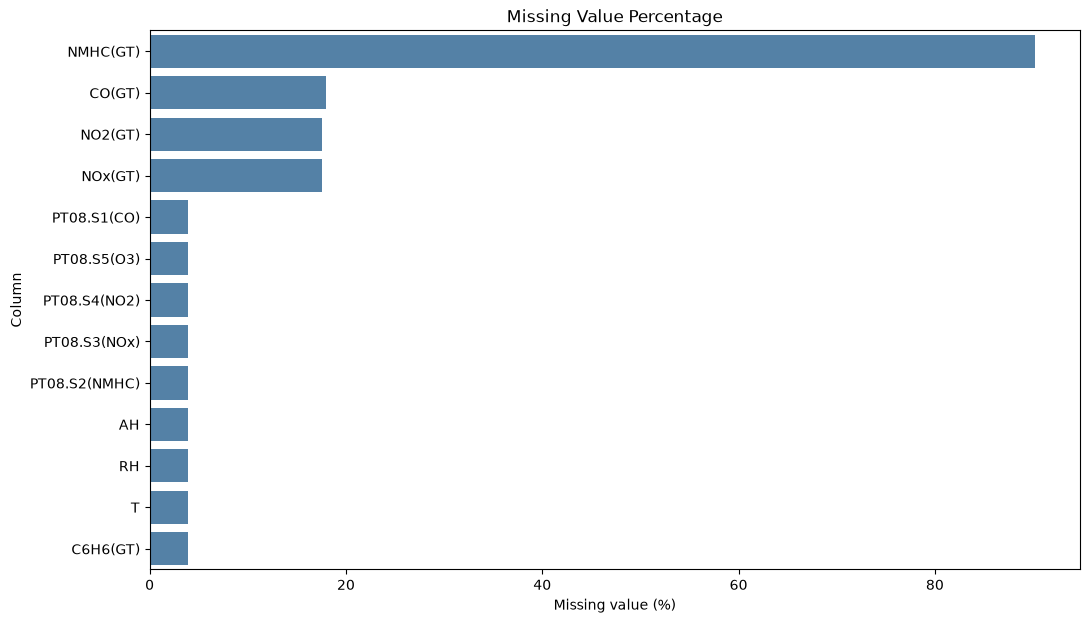

In [10]:
missing_plot = (missing_summary.reset_index().rename(columns={"index": "column"}))

plt.figure(figsize=(12, 7))

sns.barplot(
    data=missing_plot,
    x="missing_percent",
    y="column",
    color="steelblue"
)

plt.title("Missing Value Percentage")
plt.xlabel("Missing value (%)")
plt.ylabel("Column")
plt.show()

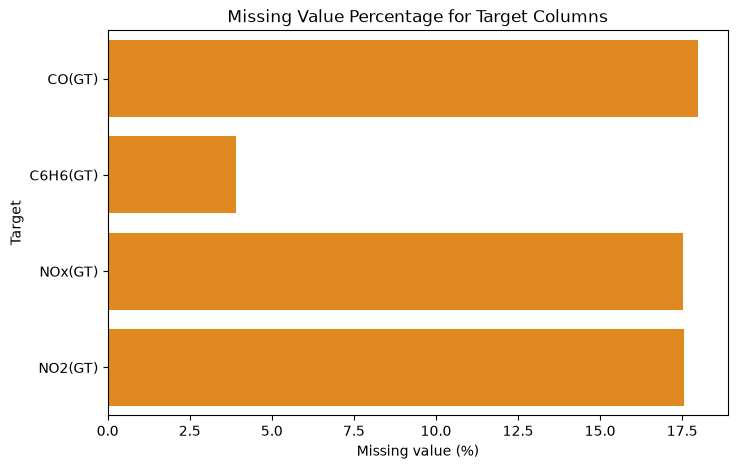

In [11]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=target_availability.reset_index(),
    x="missing_percent",
    y="index",
    color="darkorange"
)

plt.title("Missing Value Percentage for Target Columns")
plt.xlabel("Missing value (%)")
plt.ylabel("Target")
plt.show()

In [12]:
print("Number of duplicates:", df.duplicated().sum())
print("Number of empty DateTime:", df["DateTime"].isna().sum())
print("Number of duplicate DateTime:", df["DateTime"].duplicated().sum())
print("Sorted data:", df["DateTime"].is_monotonic_increasing)

Number of duplicates: 0
Number of empty DateTime: 0
Number of duplicate DateTime: 0
Sorted data: True


In [13]:
time_gap = df["DateTime"].diff().value_counts().head(10)
time_gap

DateTime
0 days 01:00:00    9356
Name: count, dtype: int64

- The dataset contains 9,357 observations with hourly measurement intervals.
- There are no invalid timestamps, duplicate timestamps, or duplicate rows.
- `C6H6(GT)` is the most complete feature: 8,991 observations (96.09%).
- `CO(GT)`, `NOx(GT)`, and `NO2(GT)` have approximately 17-18% missing values.
- Sensor and environmental features have approximately 3.91% missing values.
- `NMHC(GT)` has 90.23% missing values; therefore, it is not used as a primary feature.
- Missing target values ​​are not imputed for use as labels.

Each target should be evaluated using its own number of available observations. Missing feature values are handled within the modeling pipeline.

## Target Variable Analysis

In [14]:
target_observations = {}

for target in target_columns:
    target_df = df.dropna(subset=[target]).copy()
    target_observations[target] = target_df

    print(f"\nTarget: {target}")
    print(f"Available observations: {len(target_df):,}")
    print(f"Missing observations: {df[target].isna().sum():,}")
    print(f"Available percentage: {df[target].notna().mean() * 100:.2f}%")

target_statistics = df[target_columns].describe().T
target_statistics


Target: CO(GT)
Available observations: 7,674
Missing observations: 1,683
Available percentage: 82.01%

Target: C6H6(GT)
Available observations: 8,991
Missing observations: 366
Available percentage: 96.09%

Target: NOx(GT)
Available observations: 7,718
Missing observations: 1,639
Available percentage: 82.48%

Target: NO2(GT)
Available observations: 7,715
Missing observations: 1,642
Available percentage: 82.45%


,count,mean,std,min,25%,50%,75%,max
CO(GT),7674.0,2.152750,1.453252,0.1,1.1,1.8,2.9,11.9
C6H6(GT),8991.0,10.083105,7.449820,0.1,4.4,8.2,14.0,63.7
NOx(GT),7718.0,246.896735,212.979168,2.0,98.0,180.0,326.0,1479.0
NO2(GT),7715.0,113.091251,48.370108,2.0,78.0,109.0,142.0,340.0


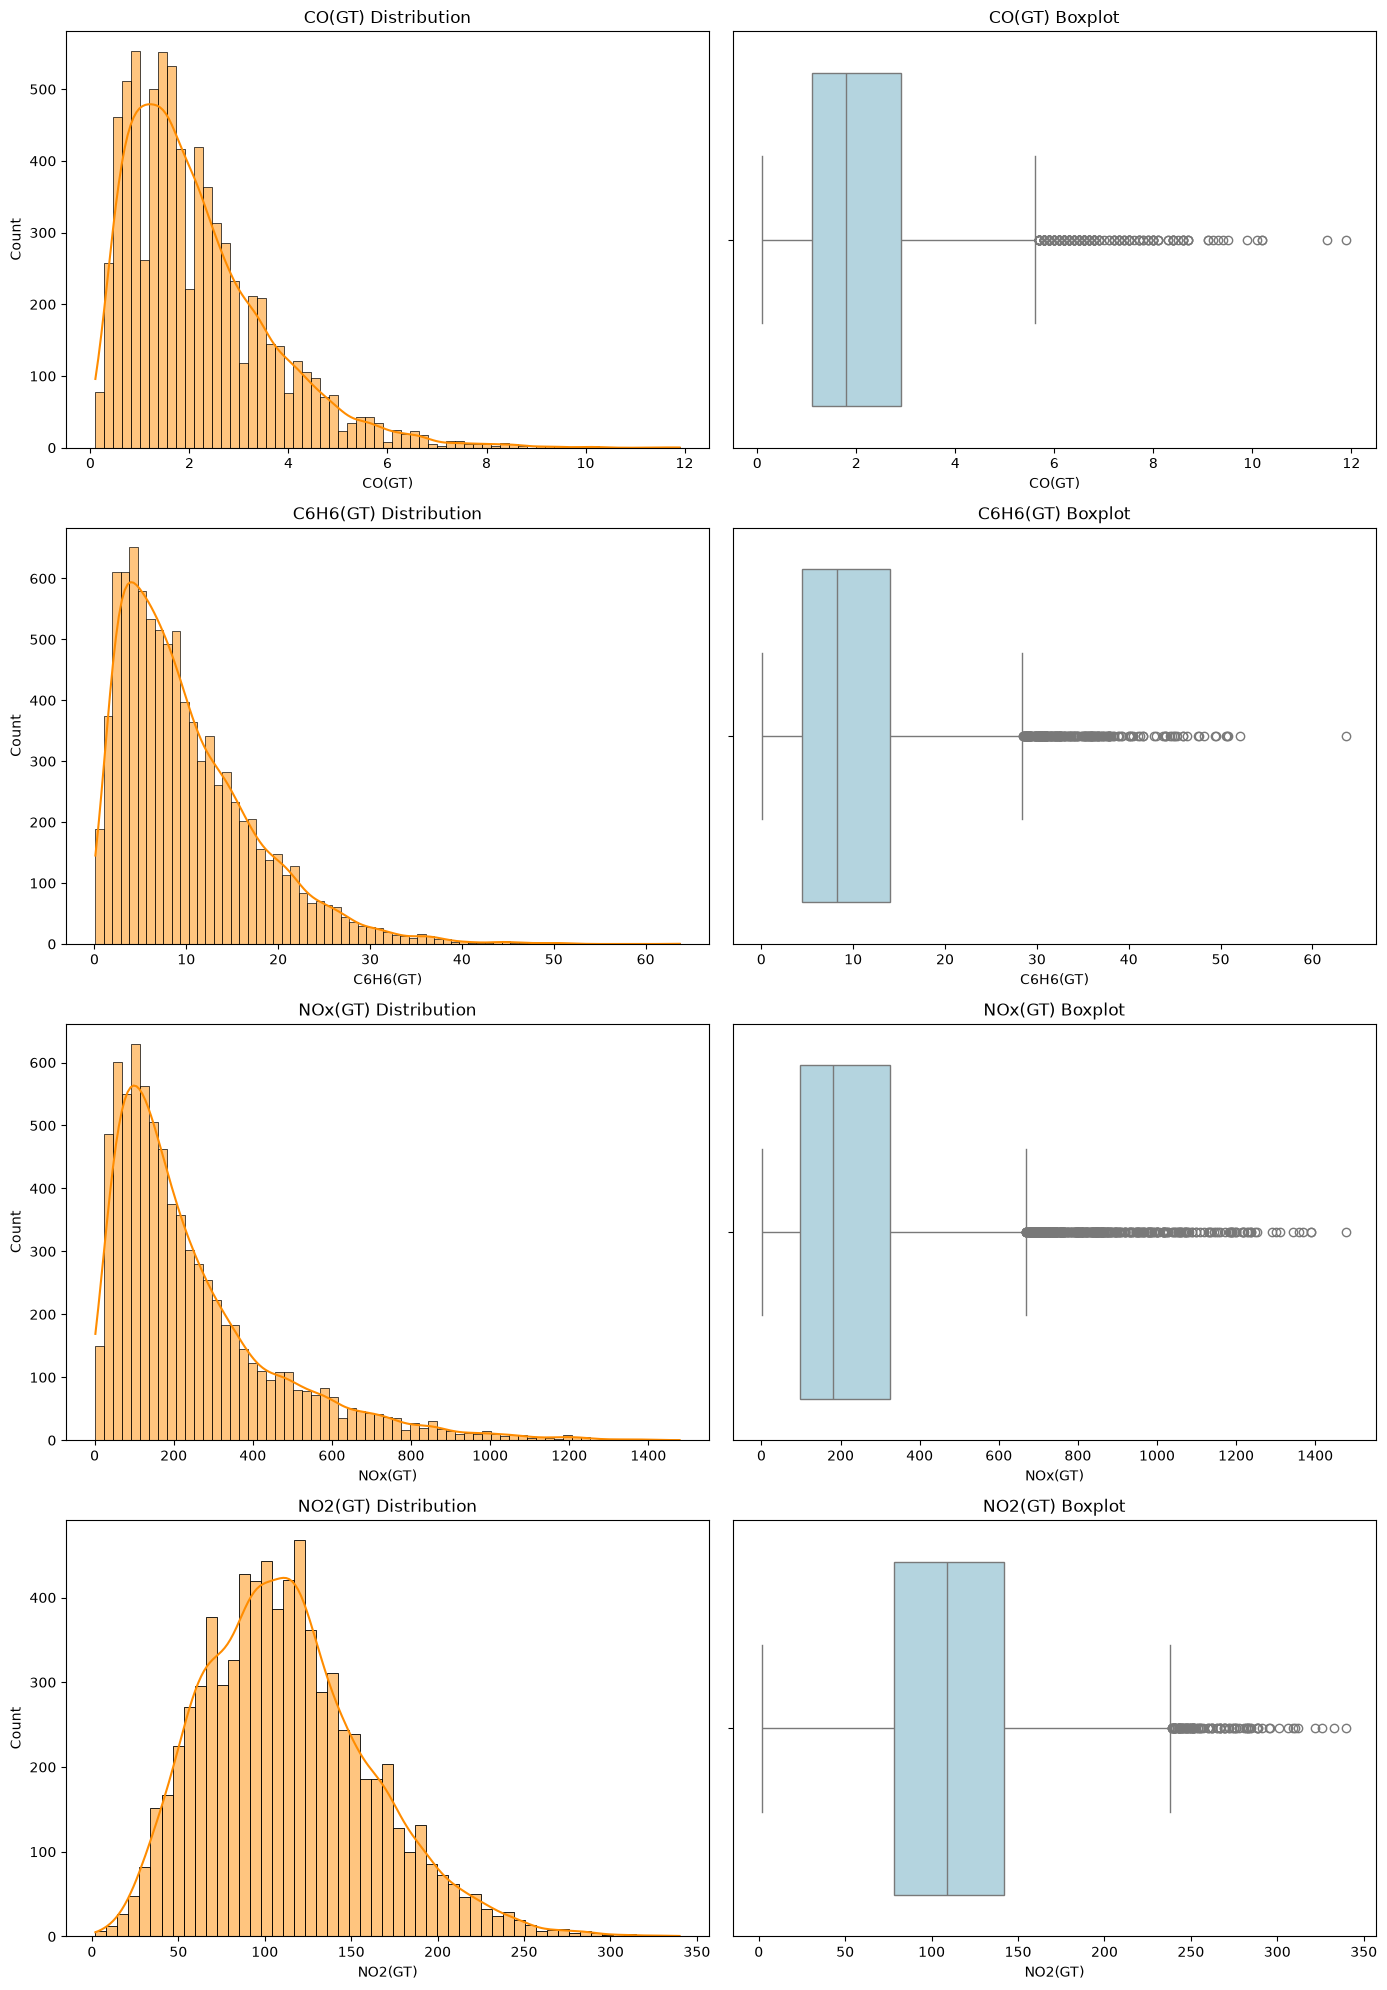

In [15]:
fig, axes = plt.subplots(len(target_columns), 2, figsize=(14, 5 * len(target_columns)))

for row, target in enumerate(target_columns):
    target_df = df.dropna(subset=[target])

    sns.histplot(
        data=target_df,
        x=target,
        kde=True,
        ax=axes[row, 0],
        color="darkorange"
    )

    axes[row, 0].set_title(f"{target} Distribution")
    axes[row, 0].set_xlabel(target)

    sns.boxplot(
        data=target_df,
        x=target,
        ax=axes[row, 1],
        color="lightblue"
    )

    axes[row, 1].set_title(f"{target} Boxplot")
    axes[row, 1].set_xlabel(target)

plt.tight_layout()
plt.show()

In [16]:
target_distribution_summary = pd.DataFrame({
    "missing_percent": df[target_columns].isna().mean() * 100,
    "count": df[target_columns].count(),
    "min": df[target_columns].min(),
    "max": df[target_columns].max(),
    "mean": df[target_columns].mean(),
    "median": df[target_columns].median(),
    "std": df[target_columns].std(),
    "skewness": df[target_columns].skew(),
    "kurtosis": df[target_columns].kurtosis(),
})

target_distribution_summary

,missing_percent,count,min,max,mean,median,std,skewness,kurtosis
CO(GT),17.986534,7674,0.1,11.9,2.152750,1.8,1.453252,1.369753,2.667779
C6H6(GT),3.911510,8991,0.1,63.7,10.083105,8.2,7.449820,1.361532,2.488706
NOx(GT),17.516298,7718,2.0,1479.0,246.896735,180.0,212.979168,1.715781,3.402134
NO2(GT),17.548360,7715,2.0,340.0,113.091251,109.0,48.370108,0.621714,0.465032


In [ ]:
outlier_columns = ( sensor_features + environment_features + target_columns)
outlier_summary = []

for column in outlier_columns:
    values = df[column].dropna()

    if pd.api.types.is_bool_dtype(values):
        continue

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = ((values < lower_bound) | (values > upper_bound))
    outlier_count = outlier_mask.sum()

    outlier_summary.append({
        "column": column,
        "outlier_count": outlier_count,
        "outlier_percent": (
            outlier_count / len(values) * 100
            if len(values) > 0
            else np.nan
        ),
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
    })

outlier_summary = (
    pd.DataFrame(outlier_summary)
    .sort_values("outlier_percent", ascending=False)
)

outlier_summary

,column,outlier_count,outlier_percent,lower_bound,upper_bound
10,NOx(GT),435,5.636175,-244.00000,668.00000
8,CO(GT),215,2.801668,-1.60000,5.60000
2,PT08.S3(NOx),241,2.680458,190.75000,1436.75000
9,C6H6(GT),228,2.535869,-10.00000,28.40000
11,NO2(GT),107,1.386909,-18.00000,238.00000
0,PT08.S1(CO),118,1.312424,496.00000,1672.00000
3,PT08.S4(NO2),97,1.078857,556.50000,2344.50000
4,PT08.S5(O3),93,1.034368,-81.50000,2086.50000
1,PT08.S2(NMHC),65,0.722945,162.25000,1688.25000
5,T,3,0.033367,-7.10000,43.30000


- `C6H6(GT)` has the most complete set of observations, whereas the other three targets have approximately 17-18% missing values.
- `NOx(GT)` is the most right-skewed, with a skewness of 1.72.
- `CO(GT)` and `C6H6(GT)` are also right-skewed, with a skewness of approximately 1.37.
- `NO2(GT)` is relatively the most symmetrical, with a skewness of 0.62.
- The highest proportion of IQR-based outlier candidates is found in `NOx(GT)`, at approximately 5.64%.
- The target distributions differ. Therefore, evaluation and preprocessing need to be assessed for each target individually.

The `log1p` transformation can be tested for skewed targets. Outliers are not automatically removed, as they may represent actual pollution episodes.

## Temporal Pattern Analysis

In [17]:
df["year"] = df["DateTime"].dt.year
df["month"] = df["DateTime"].dt.month
df["day"] = df["DateTime"].dt.day
df["day_of_week"] = df["DateTime"].dt.dayofweek
df["hour"] = df["DateTime"].dt.hour
df["is_weekend"] = df["day_of_week"] >= 5
df["day_name"] = df["DateTime"].dt.day_name()

time_features = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend"
]

feature_columns = (sensor_features + environment_features + time_features)
analysis_columns = (feature_columns + target_columns + ["NMHC(GT)"])

df[["DateTime"] + time_features].head()

,DateTime,hour,day_of_week,month,is_weekend
0,2004-03-10 18:00:00,18,2,3,False
1,2004-03-10 19:00:00,19,2,3,False
2,2004-03-10 20:00:00,20,2,3,False
3,2004-03-10 21:00:00,21,2,3,False
4,2004-03-10 22:00:00,22,2,3,False


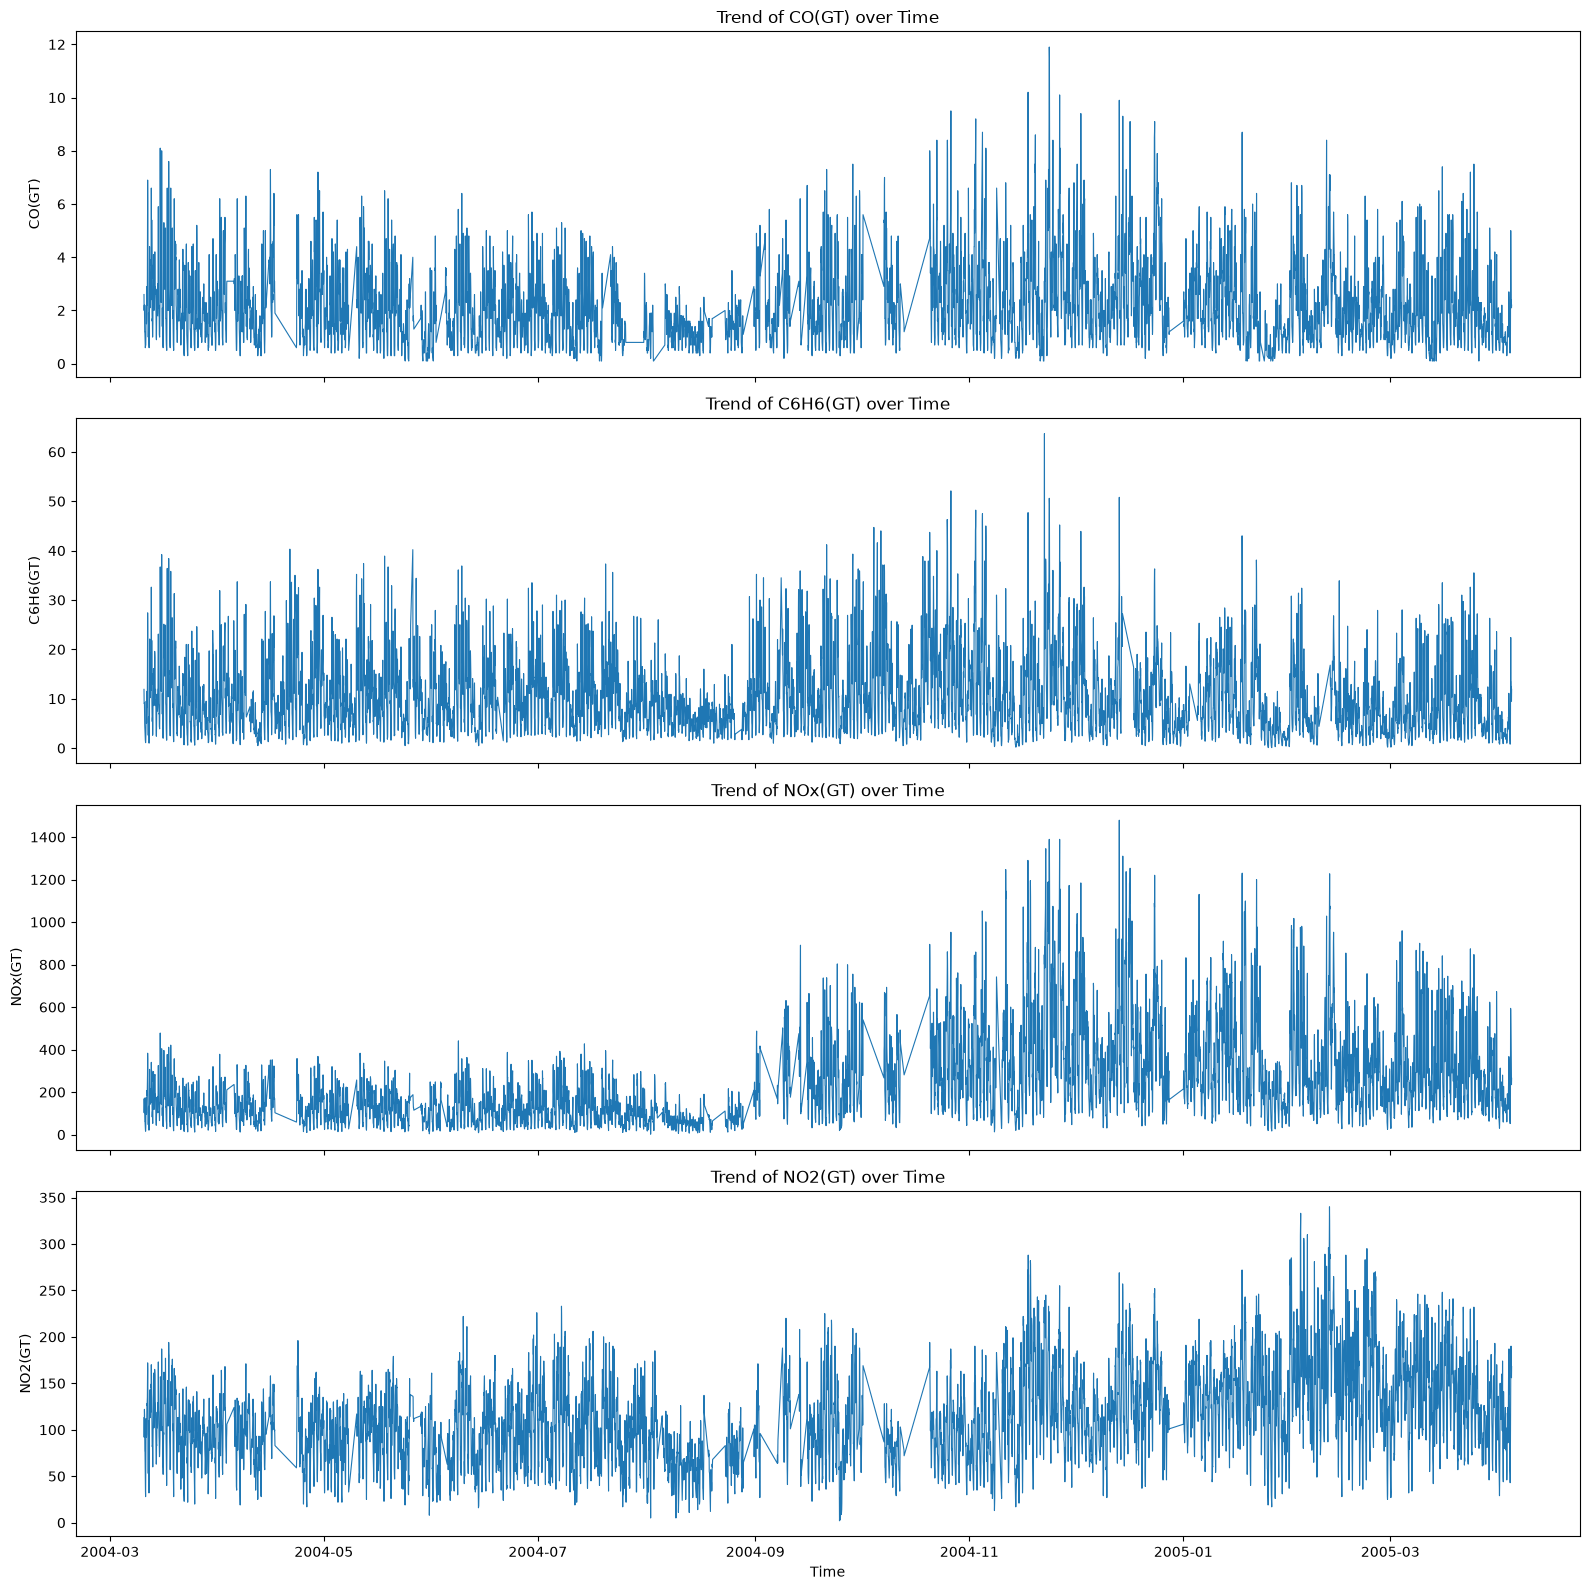

In [18]:
fig, axes = plt.subplots(len(target_columns), 1, figsize=(16, 4 * len(target_columns)), sharex=True)

for ax, target in zip(axes, target_columns):
    target_df = df.dropna(subset=[target])

    sns.lineplot(
        data=target_df,
        x="DateTime",
        y=target,
        linewidth=0.8,
        ax=ax
    )

    ax.set_title(f"Trend of {target} over Time")
    ax.set_xlabel("Time")
    ax.set_ylabel(target)

plt.tight_layout()
plt.show()

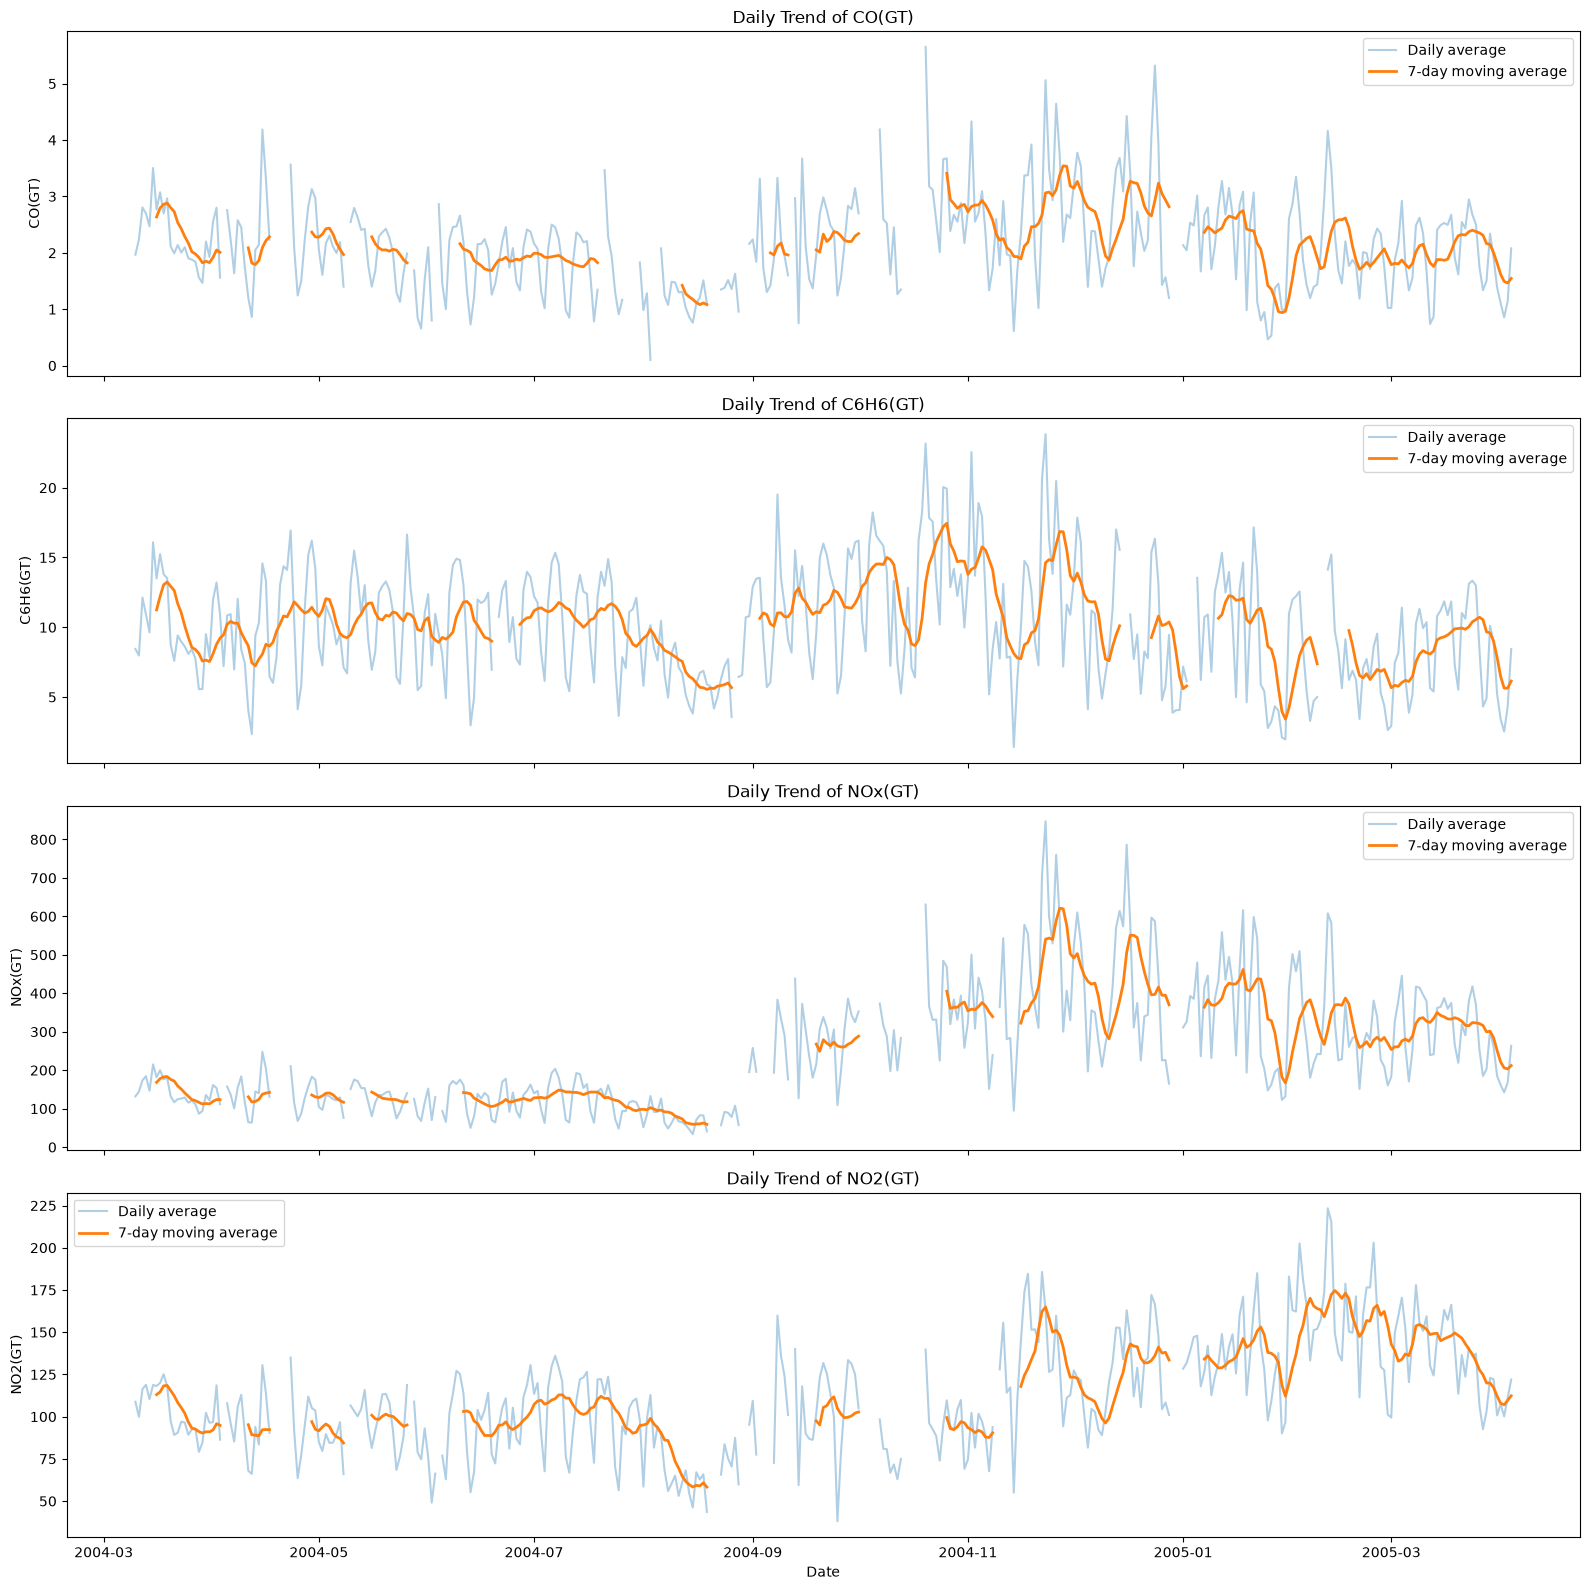

In [19]:
fig, axes = plt.subplots(len(target_columns), 1, figsize=(16, 4 * len(target_columns)), sharex=True)

for ax, target in zip(axes, target_columns):
    target_df = df.dropna(subset=[target]).set_index("DateTime")

    daily_target = target_df[target].resample("D").mean()
    rolling_target = daily_target.rolling(7).mean()

    ax.plot(daily_target, alpha=0.35, label="Daily average")
    ax.plot(rolling_target, linewidth=2, label="7-day moving average")

    ax.set_title(f"Daily Trend of {target}")
    ax.set_ylabel(target)
    ax.legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

In [20]:
hourly_target_summary = {}

for target in target_columns:
    hourly_summary = (
        df
        .groupby("hour")[target]
        .agg(["mean", "median", "std", "count"])
    )

    hourly_target_summary[target] = hourly_summary

hour_extremes = []

for target in target_columns:
    hourly_summary = hourly_target_summary[target]

    hour_extremes.append({
        "target": target,
        "peak_hour": hourly_summary["mean"].idxmax(),
        "peak_value": hourly_summary["mean"].max(),
        "minimum_hour": hourly_summary["mean"].idxmin(),
        "minimum_value": hourly_summary["mean"].min(),
    })

hour_extremes = pd.DataFrame(hour_extremes)
hour_extremes

,target,peak_hour,peak_value,minimum_hour,minimum_value
0,CO(GT),19,3.733234,5,0.712934
1,C6H6(GT),19,17.735580,4,2.916711
2,NOx(GT),19,364.002967,4,81.153614
3,NO2(GT),19,150.091988,4,58.620482


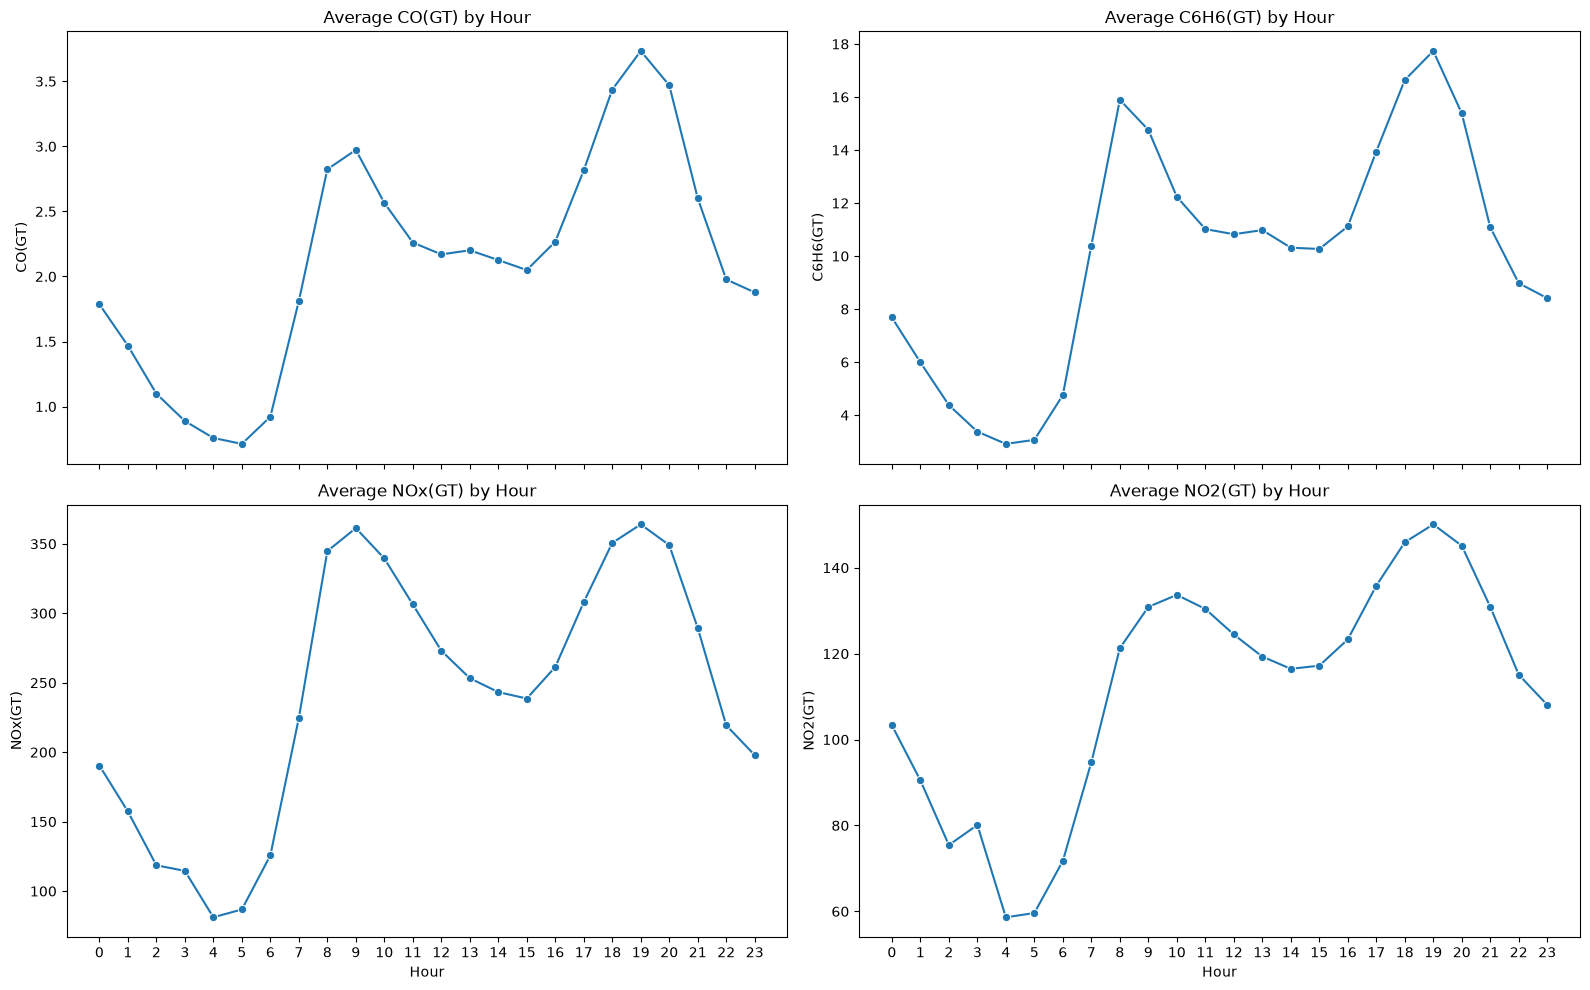

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for ax, target in zip(axes.flat, target_columns):
    hourly_summary = hourly_target_summary[target]

    sns.lineplot(
        x=hourly_summary.index,
        y=hourly_summary["mean"],
        marker="o",
        ax=ax
    )

    ax.set_title(f"Average {target} by Hour")
    ax.set_xlabel("Hour")
    ax.set_ylabel(target)
    ax.set_xticks(range(24))

plt.tight_layout()
plt.show()

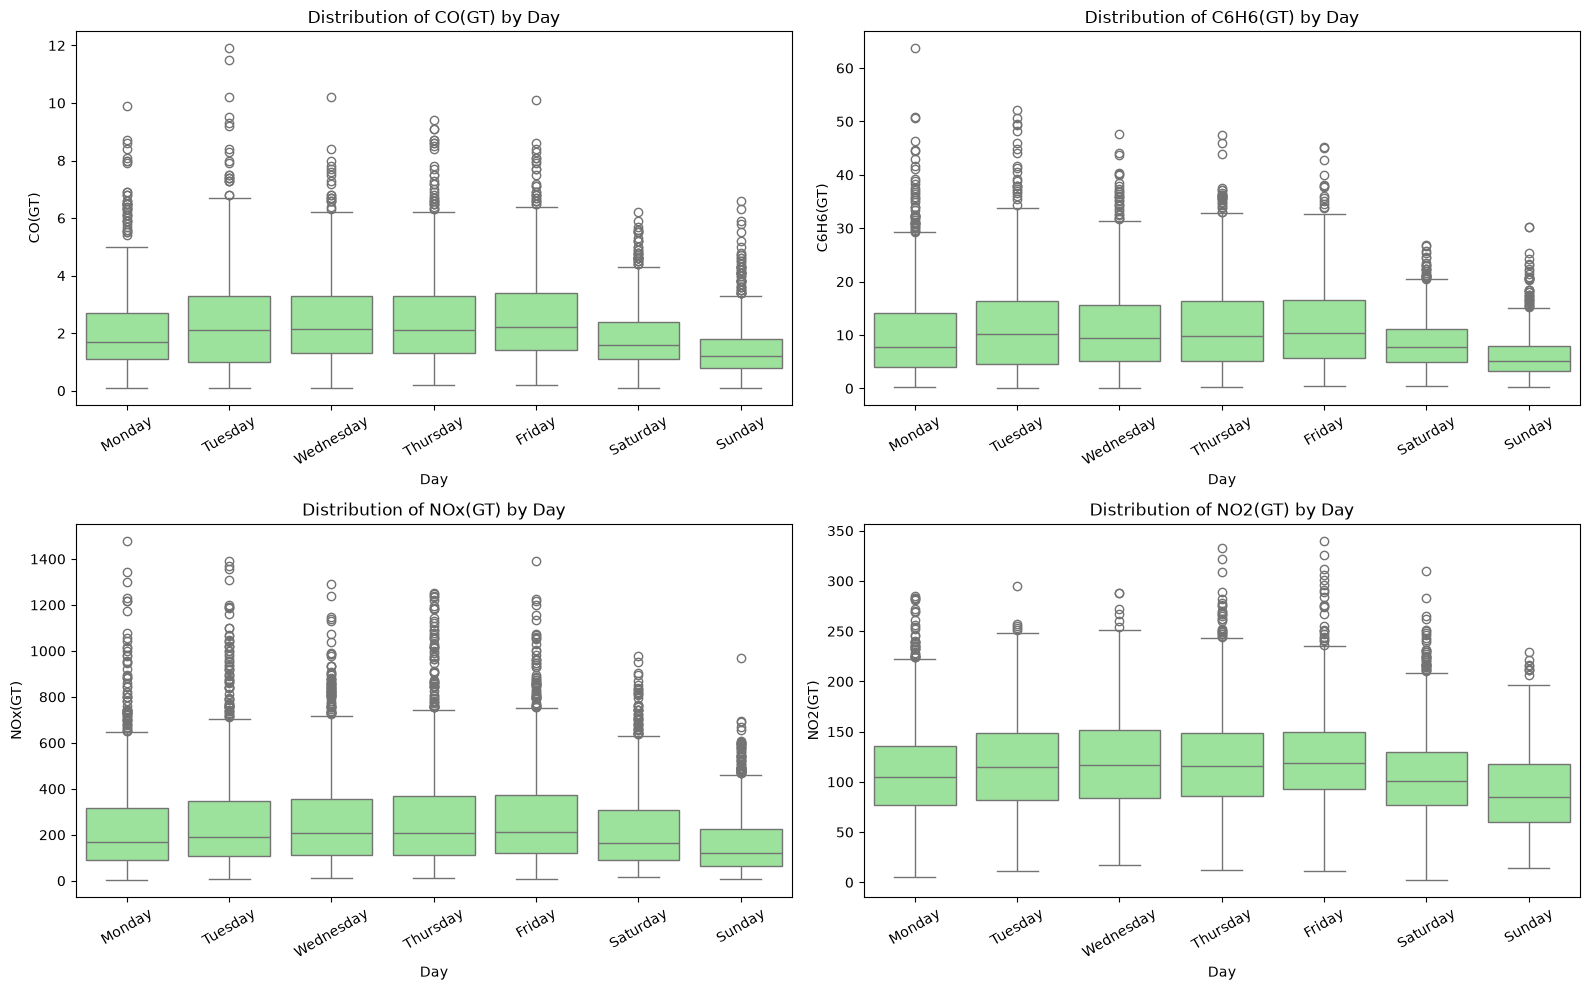

In [22]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, target in zip(axes.flat, target_columns):
    sns.boxplot(
        data=df,
        x="day_name",
        y=target,
        order=day_order,
        color="lightgreen",
        ax=ax
    )

    ax.set_title(f"Distribution of {target} by Day")
    ax.set_xlabel("Day")
    ax.set_ylabel(target)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

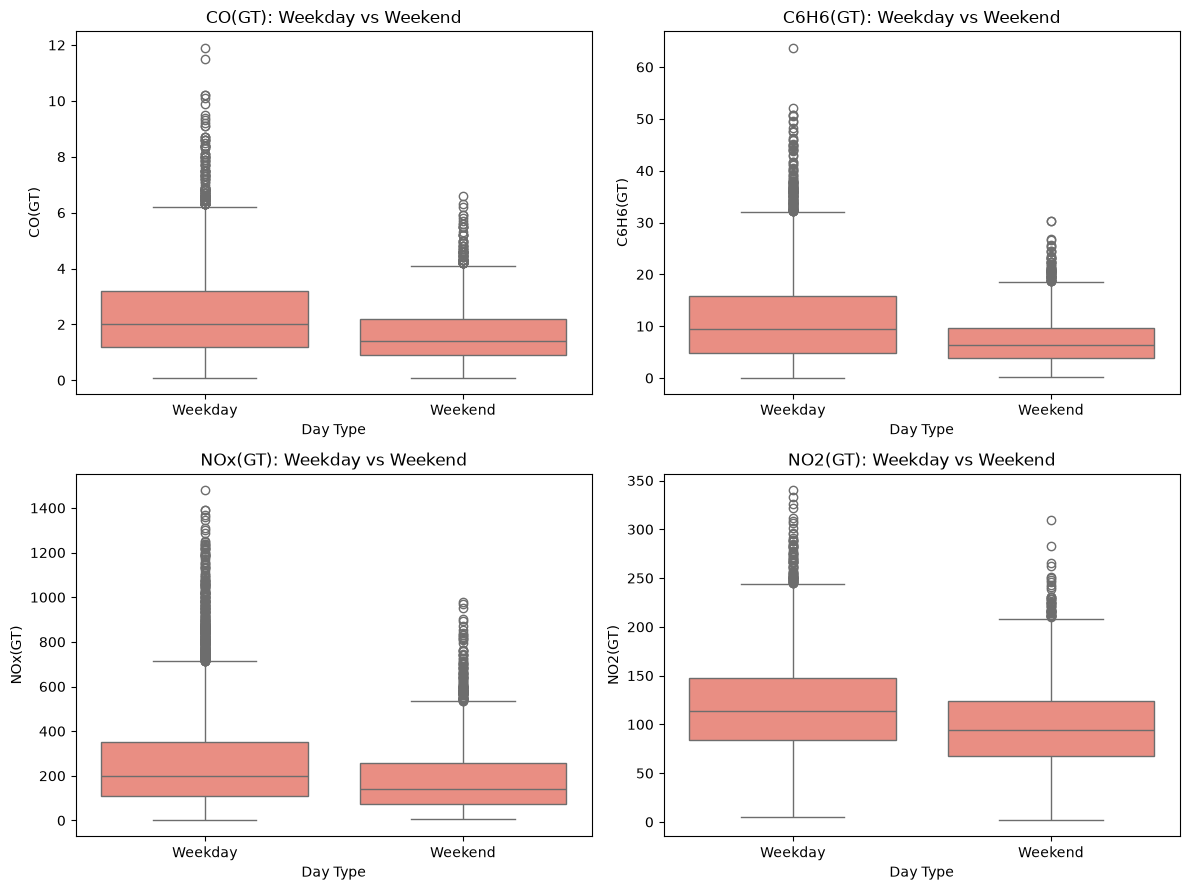

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, target in zip(axes.flat, target_columns):
    sns.boxplot(
        data=df,
        x="is_weekend",
        y=target,
        color="salmon",
        ax=ax
    )

    ax.set_title(f"{target}: Weekday vs Weekend")
    ax.set_xlabel("Day Type")
    ax.set_ylabel(target)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Weekday", "Weekend"])

plt.tight_layout()
plt.show()

In [24]:
monthly_target_summary = (
    df.groupby("month")[target_columns]
    .agg(["mean", "median", "std", "count"])
)

monthly_target_summary

CO(GT)                          C6H6(GT)                         \
           mean median       std count       mean median       std count   
month                                                                      
1      2.135059   1.70  1.413804   676   9.024597   6.90  7.210194   683   
2      2.096229   1.80  1.315306   663   7.500839   6.05  5.704324   596   
3      2.144079   1.90  1.374374  1216   9.219393   7.50  6.860827  1253   
4      2.142931   1.80  1.401566   580   9.708333   7.75  7.462206   780   
5      1.940034   1.80  1.204027   592  10.219041   9.10  6.731684   730   
6      1.900000   1.70  1.140298   644  10.595748   9.50  6.579876   682   
7      1.784946   1.60  1.098075   558  10.599462   9.90  6.231206   743   
8      1.280084   1.20  0.581762   477   6.993669   6.30  3.864837   695   
9      2.164209   1.85  1.426681   556  11.554558   9.70  8.008161   702   
10     2.724682   2.50  1.633959   393  13.525303  11.10  9.117799   743   
11     2.685420   2.30  1.927019   679  12.511806  10.10  9.838577   720   
12     2.751250   2.40  1.768654   640   9.498795   7.50  7.397054   664   

          NOx(GT)                              NO2(GT)                          
             mean median         std count        mean median        std count  
month                                                                           
1      349.819718  284.0  234.865664   710  134.781690  134.0  46.060596   710  
2      315.043614  257.0  208.883746   642  160.694704  155.5  57.969546   642  
3      243.184275  192.0  175.053883  1221  123.285831  119.0  44.068401  1221  
4      145.638743  133.0   85.900884   573   98.710297   98.0  33.627170   573  
5      122.132107  115.0   69.104642   598   93.148829   96.0  31.480119   598  
6      122.064715  108.0   79.304571   649   94.084877   93.0  39.312333   648  
7      126.754213  110.5   81.202946   712  104.120956  104.0  40.031178   711  
8       75.868526   65.0   47.038934   502   70.097804   68.0  28.262774   501  
9      280.572072  251.0  172.323012   444  108.047297  107.0  46.165274   444  
10     338.007752  315.0  186.097716   387   89.775194   88.0  31.496667   387  
11     424.188450  356.5  291.165246   658  122.531915  118.0  54.679637   658  
12     417.123794  351.5  263.797730   622  124.411576  120.0  42.168603   622

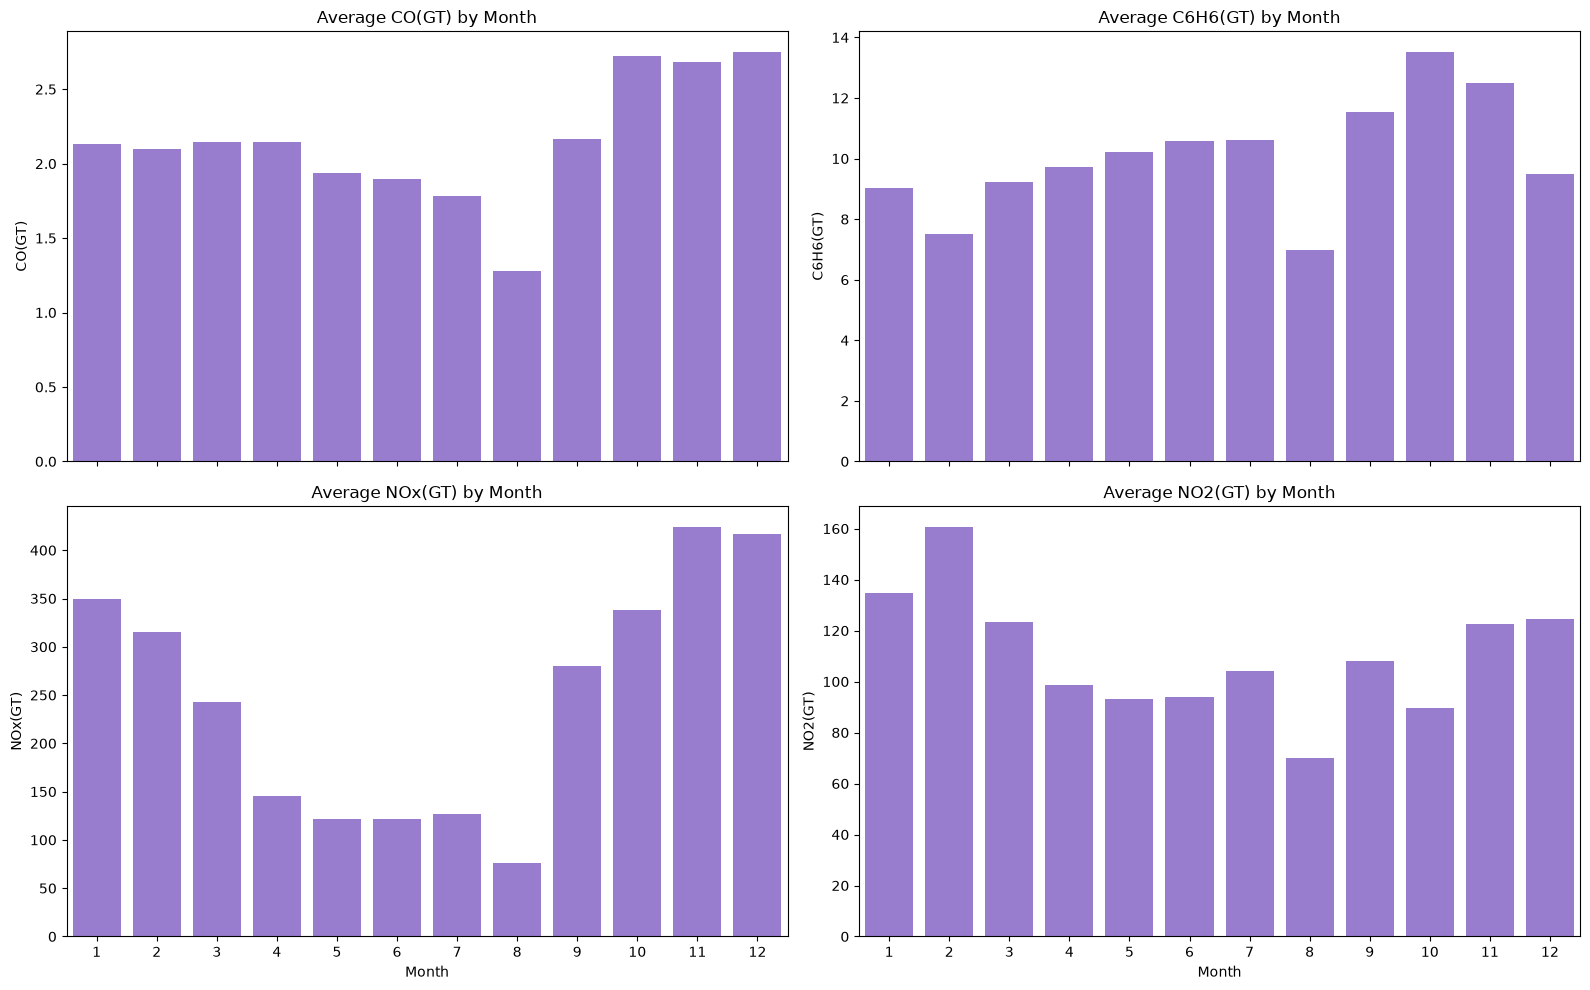

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for ax, target in zip(axes.flat, target_columns):
    monthly_summary = df.groupby("month")[target].mean()

    sns.barplot(
        x=monthly_summary.index,
        y=monthly_summary.values,
        color="mediumpurple",
        ax=ax
    )

    ax.set_title(f"Average {target} by Month")
    ax.set_xlabel("Month")
    ax.set_ylabel(target)

plt.tight_layout()
plt.show()

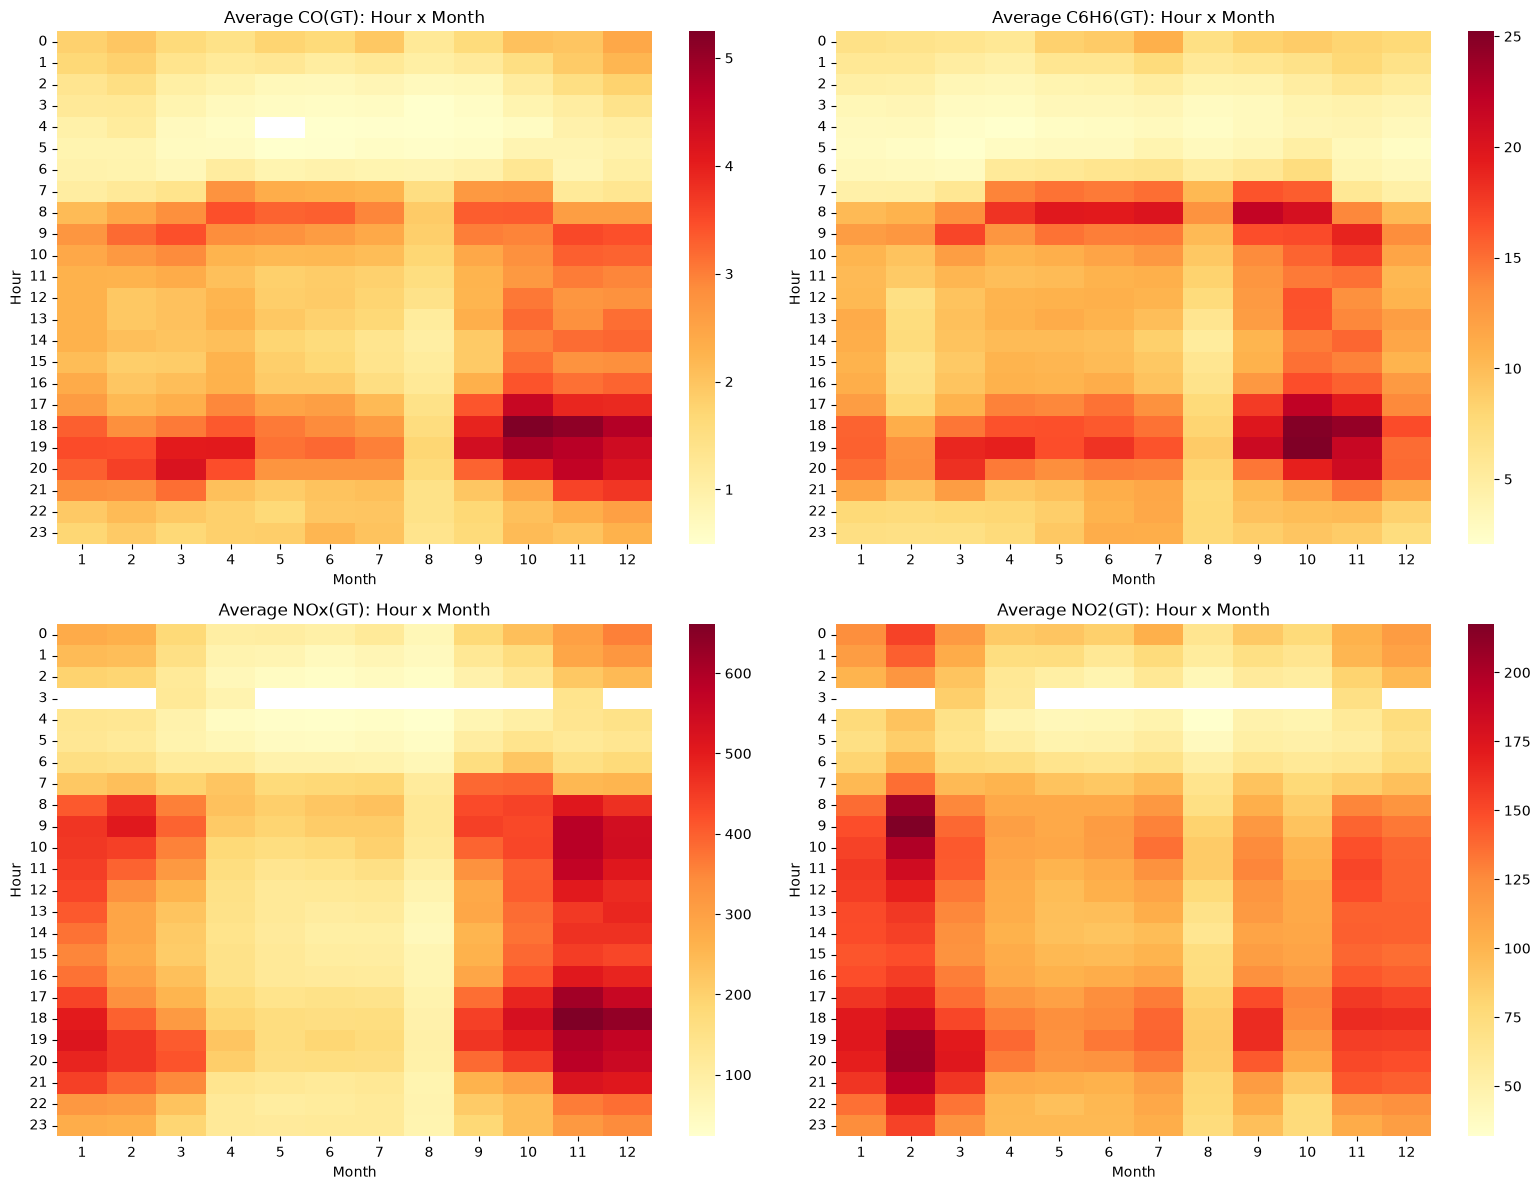

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, target in zip(axes.flat, target_columns):
    hour_month_target = df.pivot_table(
        index="hour",
        columns="month",
        values=target,
        aggfunc="mean"
    )

    sns.heatmap(
        hour_month_target,
        cmap="YlOrRd",
        annot=False,
        fmt=".1f",
        ax=ax
    )

    ax.set_title(f"Average {target}: Hour x Month")
    ax.set_xlabel("Month")
    ax.set_ylabel("Hour")

plt.tight_layout()
plt.show()

- All four targets show their highest averages around 19:00.
- The lowest values ​​generally occur around 04:00-05:00.
- The intensity of each pollutant is higher on weekdays than on weekends.
- Monthly patterns vary across the targets.
- Most pollutants reach lower concentrations around August and rise again towards the end of the year.
- The incidence of missing values ​​also varies by month; therefore, temporal averages should be interpreted in conjunction with the number of observations.

The `hour`, `month`, `day_of_week`, and `is_weekend` features are worth testing during modeling. Raw `DateTime` data is not included directly as a feature. This analysis estimates concentrations at the time of measurement rather than future values.

## Sensor and Environmental Relationship Analysis

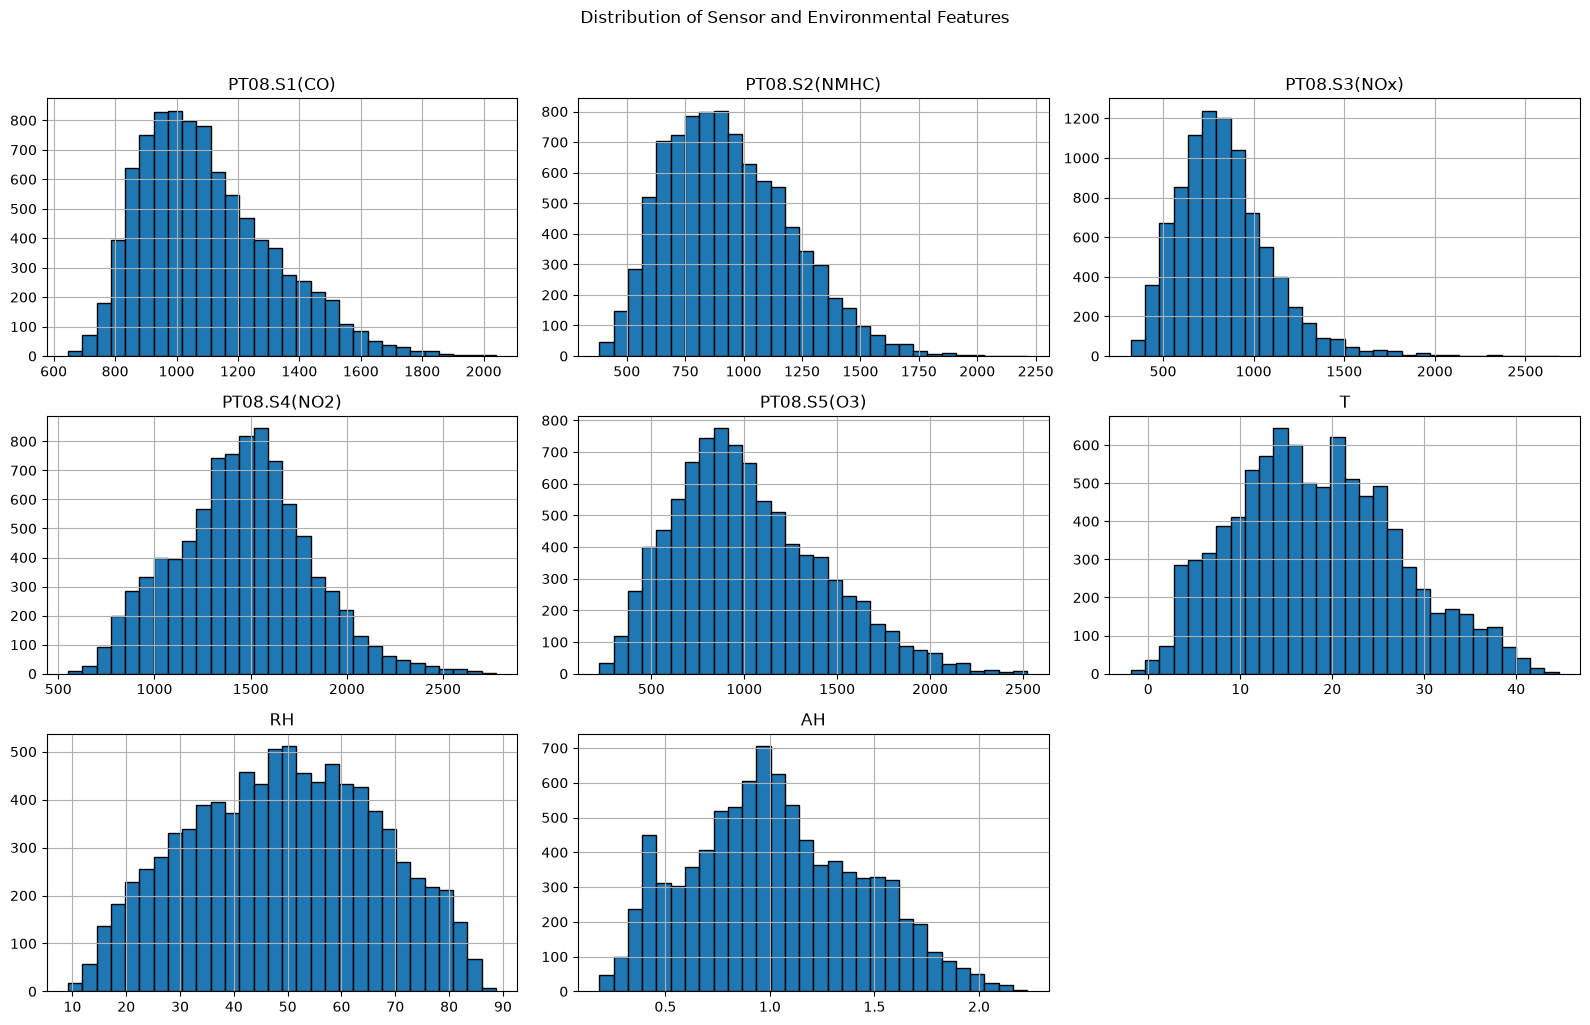

In [26]:
numeric_feature_columns = sensor_features + environment_features

df[numeric_feature_columns].hist(
    figsize=(16, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Sensor and Environmental Features",
    y=1.02
)

plt.tight_layout()
plt.show()

- Sensor and environmental features have different scales and distribution shapes.
- Sensor and environmental features have approximately 3.91% missing values.
- Extreme values ​​are not immediately removed, as they may represent real-world conditions.
- Differences in scale must be handled during the modeling stage.

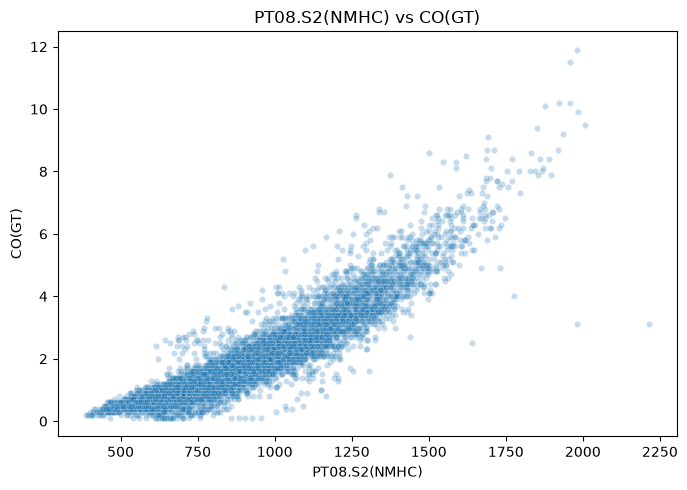

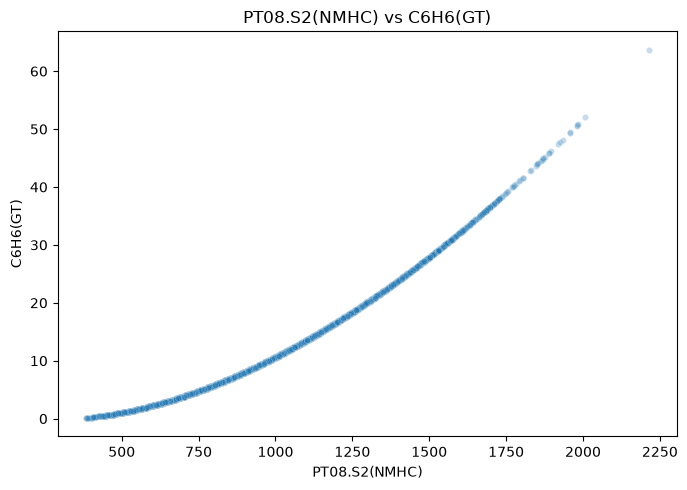

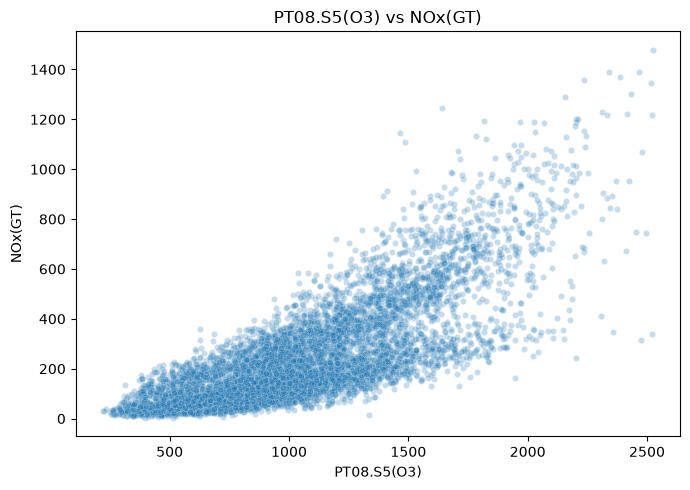

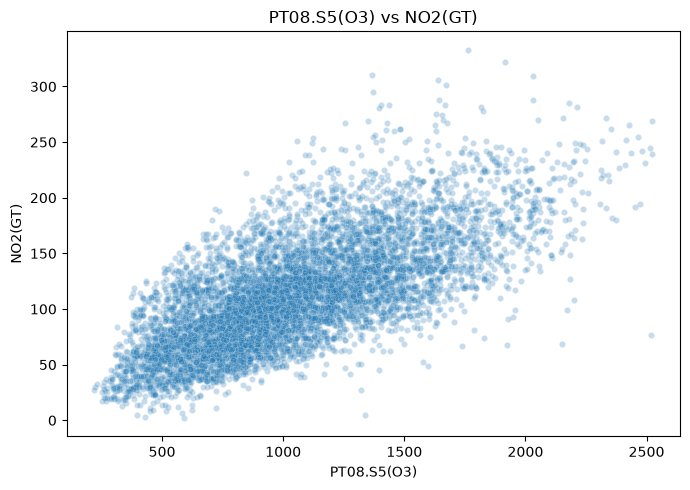

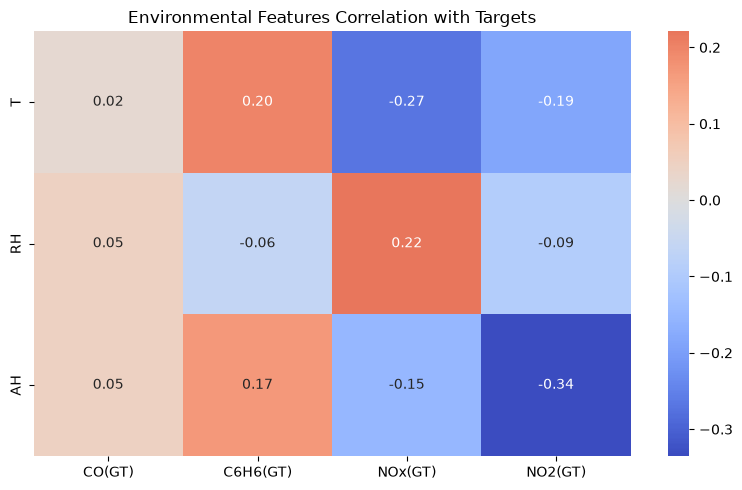

In [27]:
sensor_correlations = {}

for target in target_columns:
    ranking = (
        df[sensor_features + [target]]
        .corr()[target]
        .drop(target)
        .sort_values(key=abs, ascending=False)
    )
    sensor_correlations[target] = ranking

    top_sensor = ranking.index[0]
    fig, ax = plt.subplots(figsize=(7, 5))

    sns.scatterplot(
        data=df,
        x=top_sensor,
        y=target,
        alpha=0.25,
        s=20,
        ax=ax
    )

    ax.set_title(f"{top_sensor} vs {target}")
    ax.set_xlabel(top_sensor)
    ax.set_ylabel(target)

    plt.tight_layout()
    plt.show()

environment_correlations = (
    df[environment_features + target_columns]
    .corr()
    .loc[environment_features, target_columns]
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    environment_correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Environmental Features Correlation with Targets")
plt.tight_layout()
plt.show()

- Scatter plots show relationships between sensors and each target, though the degree of dispersion varies across pollutants.
- Correlations involving environmental features also differ depending on the target.
- The relationship with `T` is more pronounced for `C6H6(GT)`.
- The relationship with `RH` is more pronounced for `NOx(GT)`.
- The relationship with `AH` is more pronounced for `C6H6(GT)`.

## Correlation and Feature Redundancy Analysis

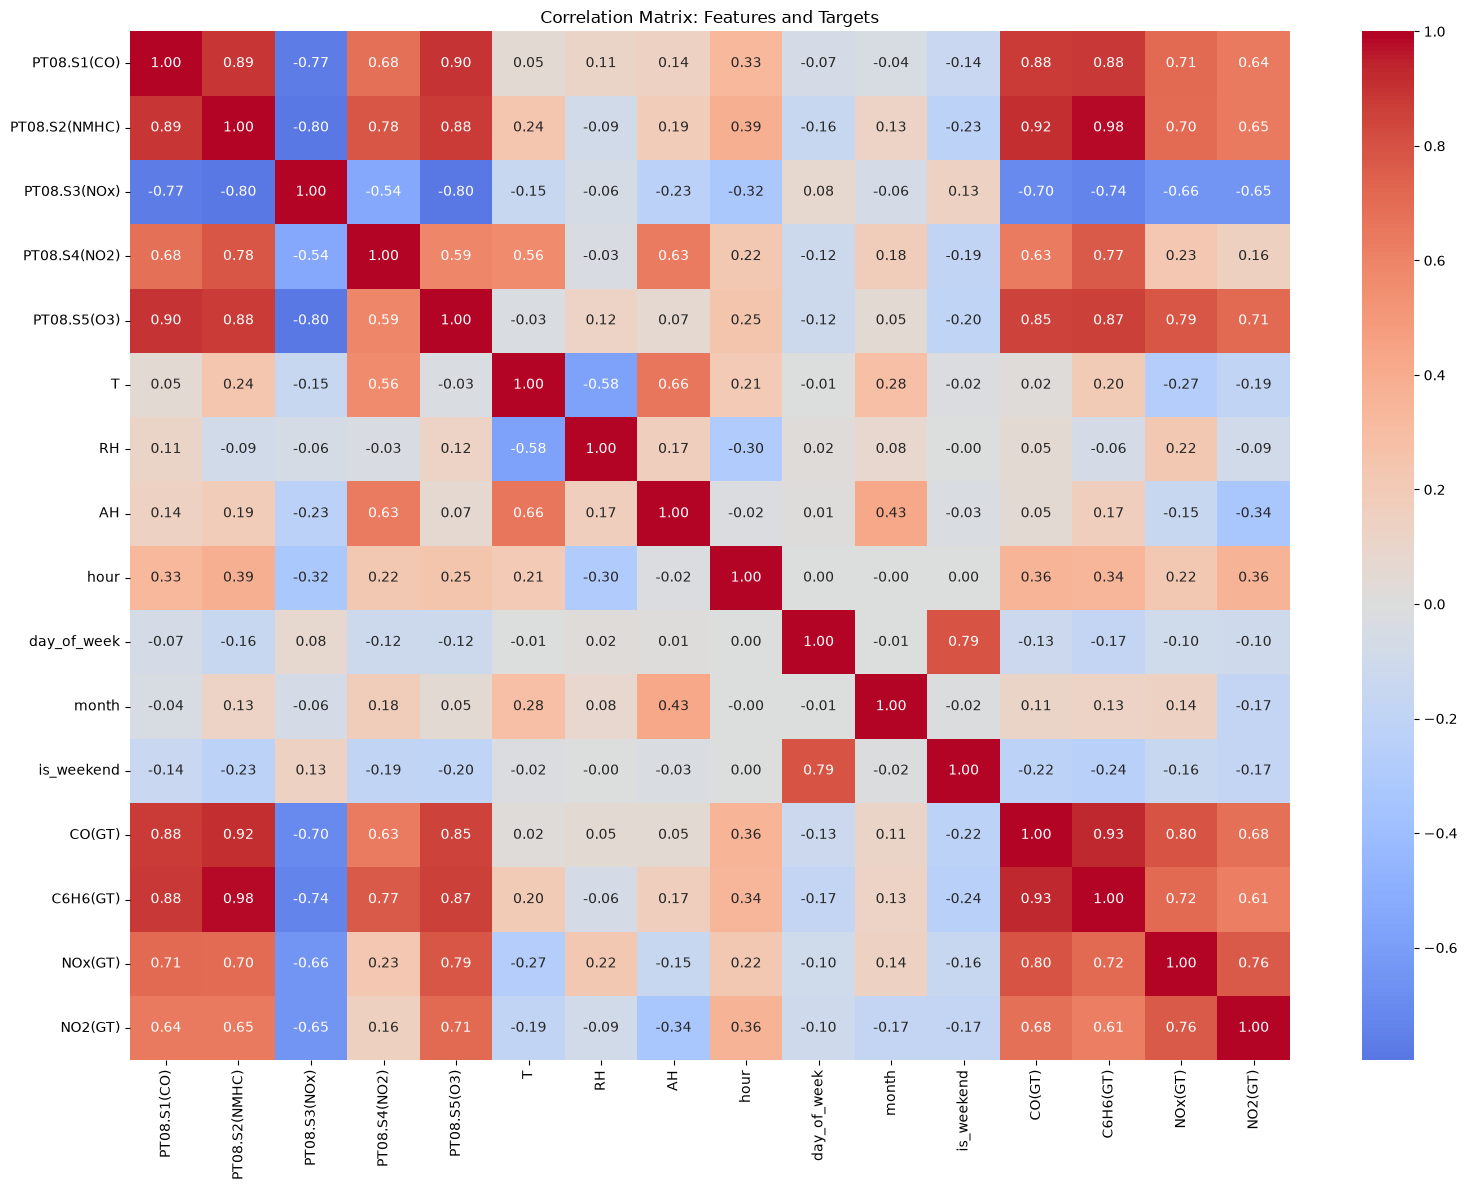

In [28]:
correlation_columns = (sensor_features + environment_features + time_features + target_columns)
correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix: Features and Targets")
plt.tight_layout()
plt.show()

In [29]:
target_correlation_rankings = {}

for target in target_columns:
    ranking = (
        correlation_matrix[target]
        .drop(target)
        .sort_values(key=abs, ascending=False)
    )

    target_correlation_rankings[target] = ranking

    print(f"\nCorrelation ranking for {target}")
    display(ranking.to_frame("correlation"))


Correlation ranking for CO(GT)


,correlation
C6H6(GT),0.931078
PT08.S2(NMHC),0.915514
PT08.S1(CO),0.879288
PT08.S5(O3),0.854182
NOx(GT),0.795028
PT08.S3(NOx),-0.703446
NO2(GT),0.683343
PT08.S4(NO2),0.630703
hour,0.358159
is_weekend,-0.220739



Correlation ranking for C6H6(GT)


,correlation
PT08.S2(NMHC),0.981950
CO(GT),0.931078
PT08.S1(CO),0.883795
PT08.S5(O3),0.865689
PT08.S4(NO2),0.765731
PT08.S3(NOx),-0.735744
NOx(GT),0.718839
NO2(GT),0.614474
hour,0.344169
is_weekend,-0.242573



Correlation ranking for NOx(GT)


,correlation
CO(GT),0.795028
PT08.S5(O3),0.787046
NO2(GT),0.763111
C6H6(GT),0.718839
PT08.S1(CO),0.713654
PT08.S2(NMHC),0.704435
PT08.S3(NOx),-0.655707
T,-0.269683
PT08.S4(NO2),0.233731
hour,0.223235



Correlation ranking for NO2(GT)


,correlation
NOx(GT),0.763111
PT08.S5(O3),0.708128
CO(GT),0.683343
PT08.S3(NOx),-0.652083
PT08.S2(NMHC),0.646245
PT08.S1(CO),0.641529
C6H6(GT),0.614474
hour,0.364853
AH,-0.335022
T,-0.186533


In [30]:
feature_correlation_matrix = df[feature_columns].corr()
feature_corr_pairs = (
    feature_correlation_matrix
    .where(
        np.triu(
            np.ones(feature_correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

feature_corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

feature_corr_pairs["absolute_correlation"] = (
    feature_corr_pairs["correlation"].abs()
)

high_redundancy_pairs = (
    feature_corr_pairs[
        feature_corr_pairs["absolute_correlation"] >= 0.80
    ]
)

high_redundancy_pairs.sort_values(
    "absolute_correlation",
    ascending=False
)

,feature_1,feature_2,correlation,absolute_correlation
4,PT08.S1(CO),PT08.S5(O3),0.899324,0.899324
1,PT08.S1(CO),PT08.S2(NMHC),0.892964,0.892964
16,PT08.S2(NMHC),PT08.S5(O3),0.880578,0.880578


- `PT08.S2(NMHC)` is the most informative for `CO(GT)` and `C6H6(GT)`.
- `PT08.S5(O3)` is the most informative for `NOx(GT)` and `NO2(GT)`.
- `PT08.S1(CO)`, `PT08.S2(NMHC)`, and `PT08.S5(O3)` exhibit high redundancy, with pairwise correlations of approximately 0.88–0.90.
- Redundancy can affect the interpretation of linear models, but it is not automatically grounds for removing features.
- The ground-truth target and `NMHC(GT)` are not used as primary input features.

## Feature Availability and Leakage Consideration

The primary input features assumed to be available at the time of estimation are PT08 sensor readings, environmental measurements (T, RH, AH), and temporal features. The CO(GT), C6H6(GT), NOx(GT), and NO2(GT) columns serve as ground-truth targets rather than primary input features. NMHC(GT) is excluded as a primary feature due to a missing value rate of approximately 90%. High correlation alone is insufficient to justify using a column as a feature, the column must also be available during deployment and must not cause data leakage. During the modeling phase, imputation and scaling parameters must be fitted to the training data following the time-based split.

## EDA Summary

In [33]:
eda_summary = pd.DataFrame({
    "missing_percent": df[analysis_columns].isna().mean() * 100,
    "available_count": df[analysis_columns].count(),
    "unique_values": df[analysis_columns].nunique(),
    "mean": df[analysis_columns].mean(),
    "median": df[analysis_columns].median(),
    "std": df[analysis_columns].std(),
})

eda_summary

,missing_percent,available_count,unique_values,mean,median,std
PT08.S1(CO),3.911510,8991,1041,1099.833166,1063.0000,217.080037
PT08.S2(NMHC),3.911510,8991,1245,939.153376,909.0000,266.831429
PT08.S3(NOx),3.911510,8991,1221,835.493605,806.0000,256.817320
PT08.S4(NO2),3.911510,8991,1603,1456.264598,1463.0000,346.206794
PT08.S5(O3),3.911510,8991,1743,1022.906128,963.0000,398.484288
T,3.911510,8991,436,18.317829,17.8000,8.832116
RH,3.911510,8991,753,49.234201,49.6000,17.316892
AH,3.911510,8991,6683,1.025530,0.9954,0.403813
hour,0.000000,9357,24,11.498557,11.0000,6.923182
day_of_week,0.000000,9357,7,3.009939,3.0000,2.000323


- The dataset exhibits a consistent temporal structure.
- The distribution of missing target values ​​varies across pollutants.
- `C6H6(GT)` has the most complete set of observations.
- `NOx(GT)` is the most skewed and has the highest number of potential outliers.
- `PT08.S2(NMHC)` shows a strong relationship with CO and Benzene.
- `PT08.S5(O3)` shows a strong relationship with NOx and NO2.
- Some sensors exhibit high redundancy.
- `NMHC(GT)` and the ground-truth target are not used as primary features.

## EDA Conclusions

- The notebook analyzes `CO(GT)`, `C6H6(GT)`, `NOx(GT)`, and `NO2(GT)` as multi-output targets.
- `C6H6(GT)` is retained as a case study from the previous analysis.
- Missing values, distributions, temporal patterns, sensor/environmental relationships, redundancies, and outliers have been analyzed for all targets.
- NMHC(GT) is excluded as a primary feature due to a high proportion of missing values.
- Ground-truth pollutant readings are not used as primary input features, despite their high correlation with other targets.
- Outliers are not automatically removed, as extreme values ​​may represent actual pollution episodes.
- Candidate features for modeling include PT08 sensor readings, T, RH, AH, and raw temporal features, cyclical encoding will be evaluated during the modeling phase.
- The modeling phase must employ a time-based split and preprocessing steps fitted solely on the training data.
- This project focuses on estimating pollutant concentrations at the time of measurement, rather than forecasting or directly estimating the AQI.